In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = {
    'Study_Hours': [2,3,4,5,6,7,8,4,6,9],
    'Attendance': [65,70,75,80,85,88,90,78,82,95],
    'Assignments': [5,6,7,8,9,10,10,7,8,10],
    'Exam_Score': [48,55,60,68,74,79,85,63,72,92]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

Dataset:
   Study_Hours  Attendance  Assignments  Exam_Score
0            2          65            5          48
1            3          70            6          55
2            4          75            7          60
3            5          80            8          68
4            6          85            9          74
5            7          88           10          79
6            8          90           10          85
7            4          78            7          63
8            6          82            8          72
9            9          95           10          92


In [6]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Study_Hours  Attendance  Assignments  Exam_Score
count    10.000000   10.000000    10.000000   10.000000
mean      5.400000   80.800000     8.000000   69.600000
std       2.221111    9.223159     1.763834   13.623509
min       2.000000   65.000000     5.000000   48.000000
25%       4.000000   75.750000     7.000000   60.750000
50%       5.500000   81.000000     8.000000   70.000000
75%       6.750000   87.250000     9.750000   77.750000
max       9.000000   95.000000    10.000000   92.000000



Correlation Matrix:
             Study_Hours  Attendance  Assignments  Exam_Score
Study_Hours     1.000000    0.986056     0.964292    0.997305
Attendance      0.986056    1.000000     0.976688    0.993221
Assignments     0.964292    0.976688     1.000000    0.966400
Exam_Score      0.997305    0.993221     0.966400    1.000000


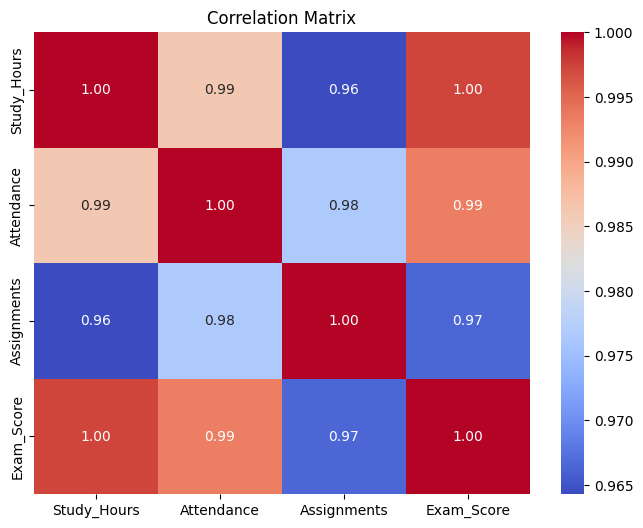

In [8]:
print("\nCorrelation Matrix:")
corr_matrix = df.corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

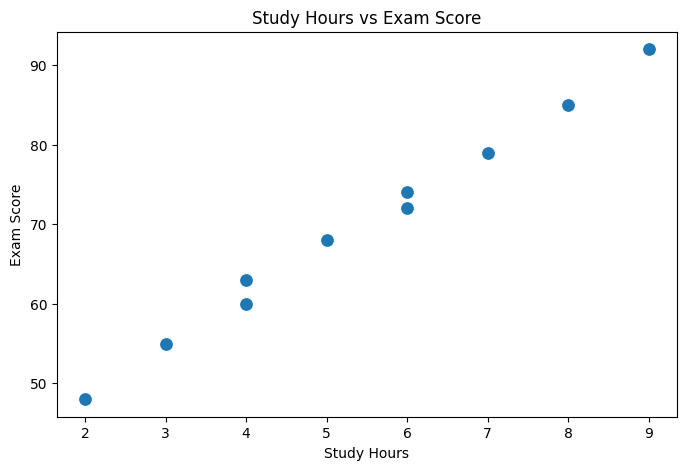

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Study_Hours',
                y='Exam_Score',
                data=df,
                s=100)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

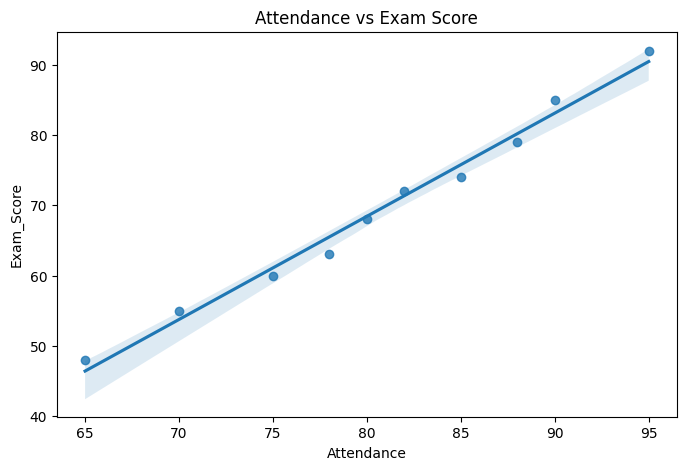

In [12]:
plt.figure(figsize=(8,5))
sns.regplot(x='Attendance',
            y='Exam_Score',
            data=df)

plt.title("Attendance vs Exam Score")
plt.show()

In [14]:
X = df[['Study_Hours', 'Attendance', 'Assignments']]
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

In [20]:
print("\nModel Performance")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("MSE:", round(mean_squared_error(y_test, y_pred), 3))


Model Performance
R² Score: 0.991
MSE: 0.64


In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
       Feature  Coefficient
0  Study_Hours     4.147595
1   Attendance     0.665008
2  Assignments    -0.920398


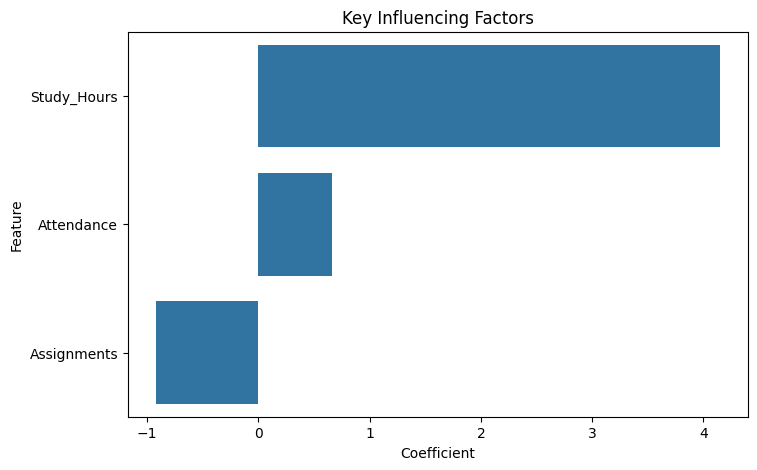

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Key Influencing Factors")
plt.show()

In [28]:
print("\n===== INSIGHTS REPORT =====")

top_feature = importance.iloc[0]['Feature']

print(f"Most Influential Factor: {top_feature}")

print("""
Key Findings:
1. Higher study hours generally lead to higher exam scores.
2. Attendance shows a strong positive relationship with performance.
3. Assignment completion contributes significantly to success.
4. The machine learning model predicts exam scores using these factors.
5. Correlation analysis helps identify the strongest relationships.
""")


===== INSIGHTS REPORT =====
Most Influential Factor: Study_Hours

Key Findings:
1. Higher study hours generally lead to higher exam scores.
2. Attendance shows a strong positive relationship with performance.
3. Assignment completion contributes significantly to success.
4. The machine learning model predicts exam scores using these factors.
5. Correlation analysis helps identify the strongest relationships.

